In [1]:
import anndata as ad
import os
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import pandas as pd

## Download results

In [4]:
def dict_to_pd(d):
    rows = []

    for outer_key, inner in d.items():
        row = {
            "dataset_id": inner["dataset_id"],
            "method_id": inner["method_id"],
        }
        
        # Use values from "d" as column names
        for col_name, value in zip(inner["metric_ids"], inner["metric_values"]):
            row[col_name] = value
            
        rows.append(row)
    
    df = pd.DataFrame(rows, index=d.keys())
    return df

In [5]:
methods_path = '../../data_lpm_style_learning_missed/benchmark/results/metrics/methods/'

In [ ]:
'../../data_lpm_style_learning_missed/benchmark/results/metrics/methods/nn_retraining_with_pseudolabels_mol_emb_learning_missed_subsample_lpm_concat_dense_all_30/'

In [7]:
os.listdir(methods_path + 'nn_retraining_with_pseudolabels_mol_emb_learning_missed_subsample_lpm_concat_dense_all_30/stability')

['seed_10',
 'seed_11',
 'seed_4',
 'seed_3',
 'seed_14',
 'seed_1',
 'seed_2',
 'seed_12',
 'seed_0',
 'seed_13']

In [8]:
file_name_err = 'mean_rowwise_error.h5ad'
file_name_corr = 'mean_rowwise_correlation.h5ad'

In [9]:
methods_err = {}
methods_corr = {}
for item in os.listdir(methods_path):
    if 'mol_emb_learning' in item:
        if 'nn_retraining_with_pseudolabels_mol_emb_subsample_fp' in item:
            name = item.replace('_all_1', '')
        else:
            name = item
        name = name.replace('nn_retraining_with_pseudolabels_mol_emb_learning_missed_subsample_', '')
        stability_path = methods_path + item + '/stability'
        for seed in os.listdir(stability_path):
            
            err = ad.read_h5ad(f'{stability_path}/{seed}/{file_name_err}').uns
            corr = ad.read_h5ad(f'{stability_path}/{seed}/{file_name_corr}').uns
            methods_err[name + '_' + seed] = err
            methods_corr[name + '_' + seed] = corr

In [23]:
df_method_err = dict_to_pd(methods_err)

In [24]:
df_method_corr = dict_to_pd(methods_corr)

In [25]:
df_method_err['method_name'] = df_method_err.index.str.split('_seed_').str[0]
df_method_err['seed'] = df_method_err.index.str.split('_seed_').str[1].astype(int)

In [26]:
df_method_corr['method_name'] = df_method_corr.index.str.split('_seed_').str[0]
df_method_corr['seed'] = df_method_corr.index.str.split('_seed_').str[1].astype(int)

In [27]:
len(df_method_corr['method_name'].unique())

40

In [28]:
df_method_corr = pd.concat([df_method_corr_, df_method_corr.reset_index()])
df_method_err = pd.concat([df_method_err_, df_method_err.reset_index()])

## Mean rowwise error

### Methods

In [29]:
df_method_err.sort_values(by="mean_rowwise_rmse")

,index,dataset_id,method_id,mean_rowwise_rmse,mean_rowwise_mae,method_name,seed
230,lpm_trainable_all_20_seed_10,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.802382,0.566639,lpm_trainable_all_20,10
235,lpm_trainable_all_20_seed_1,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.802922,0.567278,lpm_trainable_all_20,1
239,lpm_trainable_all_20_seed_13,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.802923,0.567252,lpm_trainable_all_20,13
232,lpm_trainable_all_20_seed_4,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.803084,0.566383,lpm_trainable_all_20,4
237,lpm_trainable_all_20_seed_12,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.803332,0.567428,lpm_trainable_all_20,12
...,...,...,...,...,...,...,...
80,lpm_fixed_all_40_seed_10,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_fixed,0.882389,0.635262,lpm_fixed_all_40,10
119,lpm_fixed_all_35_seed_10,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_fixed,0.882965,0.635752,lpm_fixed_all_35,10
88,lpm_fixed_all_40_seed_0,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_fixed,0.882973,0.636255,lpm_fixed_all_40,0
296,lpm_fixed_all_45_seed_0,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_fixed,0.885197,0.637820,lpm_fixed_all_45,0


In [30]:
df_method_err

,index,dataset_id,method_id,mean_rowwise_rmse,mean_rowwise_mae,method_name,seed
0,lpm_concat_not_dense_all_25_seed_12,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_co...,0.817255,0.577408,lpm_concat_not_dense_all_25,12
1,lpm_concat_not_dense_all_25_seed_2,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_co...,0.818331,0.578670,lpm_concat_not_dense_all_25,2
2,lpm_concat_not_dense_all_25_seed_14,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_co...,0.816970,0.576908,lpm_concat_not_dense_all_25,14
3,lpm_concat_not_dense_all_25_seed_10,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_co...,0.818126,0.577890,lpm_concat_not_dense_all_25,10
4,lpm_concat_not_dense_all_25_seed_3,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_co...,0.817832,0.577472,lpm_concat_not_dense_all_25,3
...,...,...,...,...,...,...,...
395,lpm_concat_not_dense_all_50_seed_10,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_co...,0.817663,0.577454,lpm_concat_not_dense_all_50,10
396,lpm_concat_not_dense_all_50_seed_11,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_co...,0.817476,0.577529,lpm_concat_not_dense_all_50,11
397,lpm_concat_not_dense_all_50_seed_13,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_co...,0.815905,0.575757,lpm_concat_not_dense_all_50,13
398,lpm_concat_not_dense_all_50_seed_3,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_co...,0.816945,0.576727,lpm_concat_not_dense_all_50,3


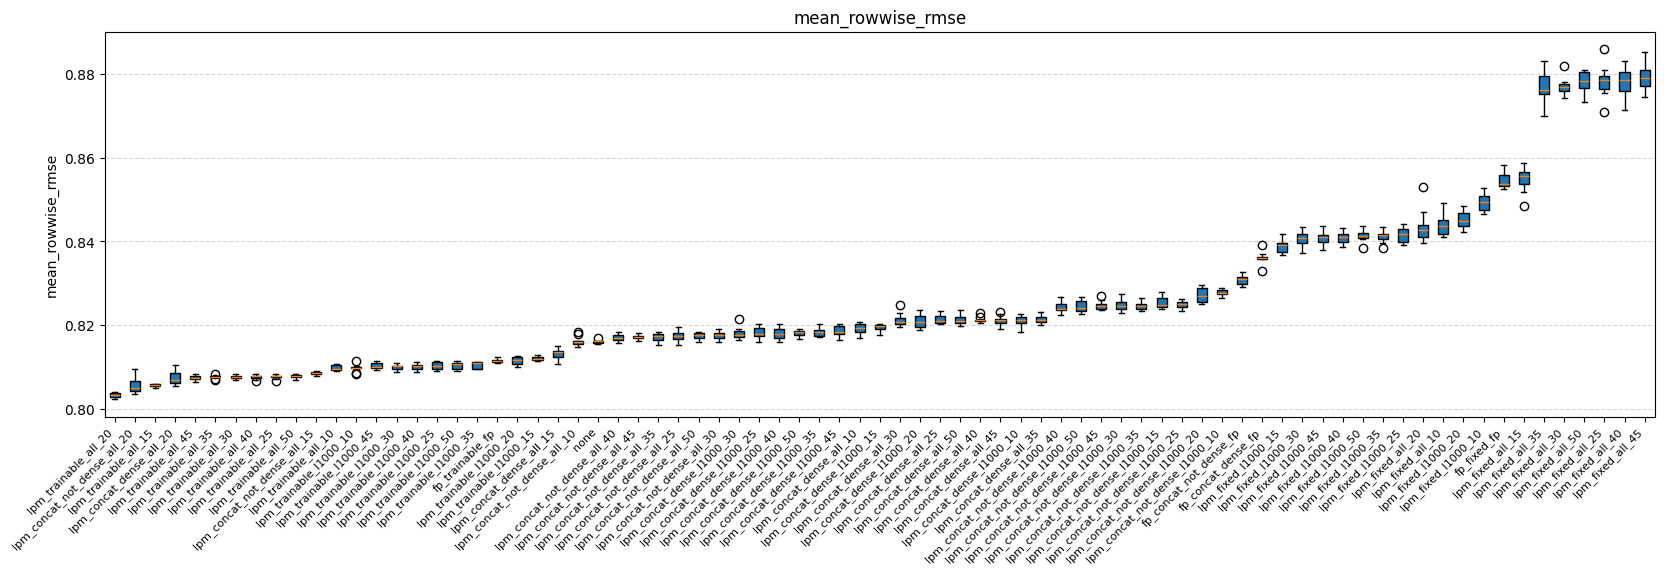

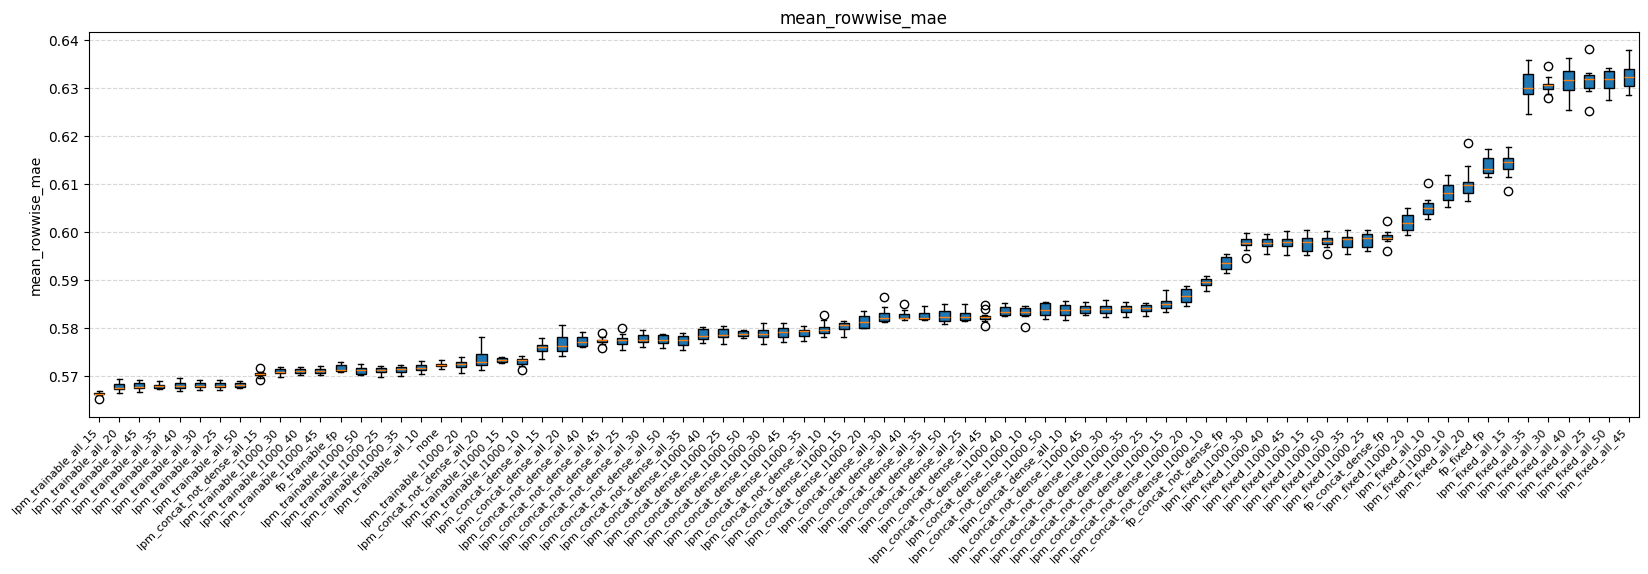

In [31]:
metrics = ["mean_rowwise_rmse", "mean_rowwise_mae"]
#fig, axes = plt.subplots(1, len(metrics), figsize=(6 * len(metrics), 5))
for metric in metrics:
    # collect values per method, ordered by median
    methods_ordered = (
        df_method_err.groupby("method_name")[metric]
        .median()
        .sort_values()
        .index.tolist()
    )
    data_per_method = [
        df_method_err.loc[df_method_err["method_name"] == m, metric].values
        for m in methods_ordered
    ]
    plt.figure(figsize=(20, 5))
    plt.boxplot(data_per_method, patch_artist=True, vert=True)
    plt.xticks(
        range(1, len(methods_ordered) + 1),
        # strip the long common prefix for readability
        [m.replace("nn_retraining_with_pseudolabels_mol_emb_subsample_", "") for m in methods_ordered],
        rotation=45, ha="right", fontsize=8,
    )
    plt.ylabel(metric)
    plt.title(metric)
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()
#fig.suptitle("Stability across seeds", fontsize=13, y=1.02)
#plt.tight_layout()


## Mean rowwise correlation

### Methods

In [32]:
df_method_corr.sort_values(by="mean_rowwise_pearson", ascending=False)
#df_method_corr.sort_values(by="mean_rowwise_spearman", ascending=False)

,index,dataset_id,method_id,mean_rowwise_pearson,mean_rowwise_spearman,mean_rowwise_cosine,method_name,seed
274,lpm_trainable_all_15_seed_4,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.288204,0.277027,0.292207,lpm_trainable_all_15,4
279,lpm_trainable_all_15_seed_0,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.288038,0.276683,0.291921,lpm_trainable_all_15,0
235,lpm_trainable_all_20_seed_1,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.287489,0.275914,0.291325,lpm_trainable_all_20,1
277,lpm_trainable_all_15_seed_12,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.287441,0.275562,0.291394,lpm_trainable_all_15,12
272,lpm_trainable_all_15_seed_2,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.287421,0.276341,0.291330,lpm_trainable_all_15,2
...,...,...,...,...,...,...,...,...
343,lpm_fixed_l1000_15_seed_11,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_fixed,0.226380,0.214098,0.230643,lpm_fixed_l1000_15,11
66,lpm_fixed_all_15_seed_11,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_fixed,0.226270,0.216435,0.230287,lpm_fixed_all_15,11
34,lpm_fixed_all_30_seed_4,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_fixed,0.225224,0.213979,0.228739,lpm_fixed_all_30,4
58,lpm_fixed_all_50_seed_13,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_fixed,0.224928,0.213844,0.228580,lpm_fixed_all_50,13


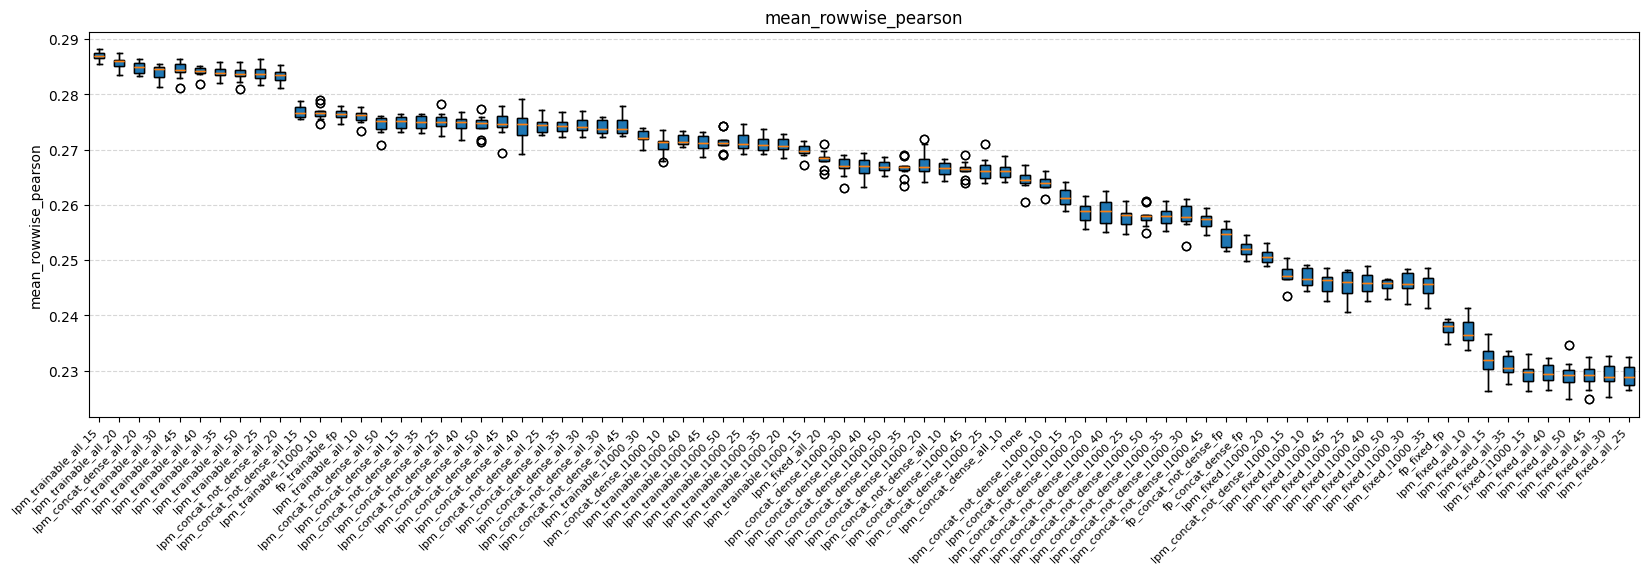

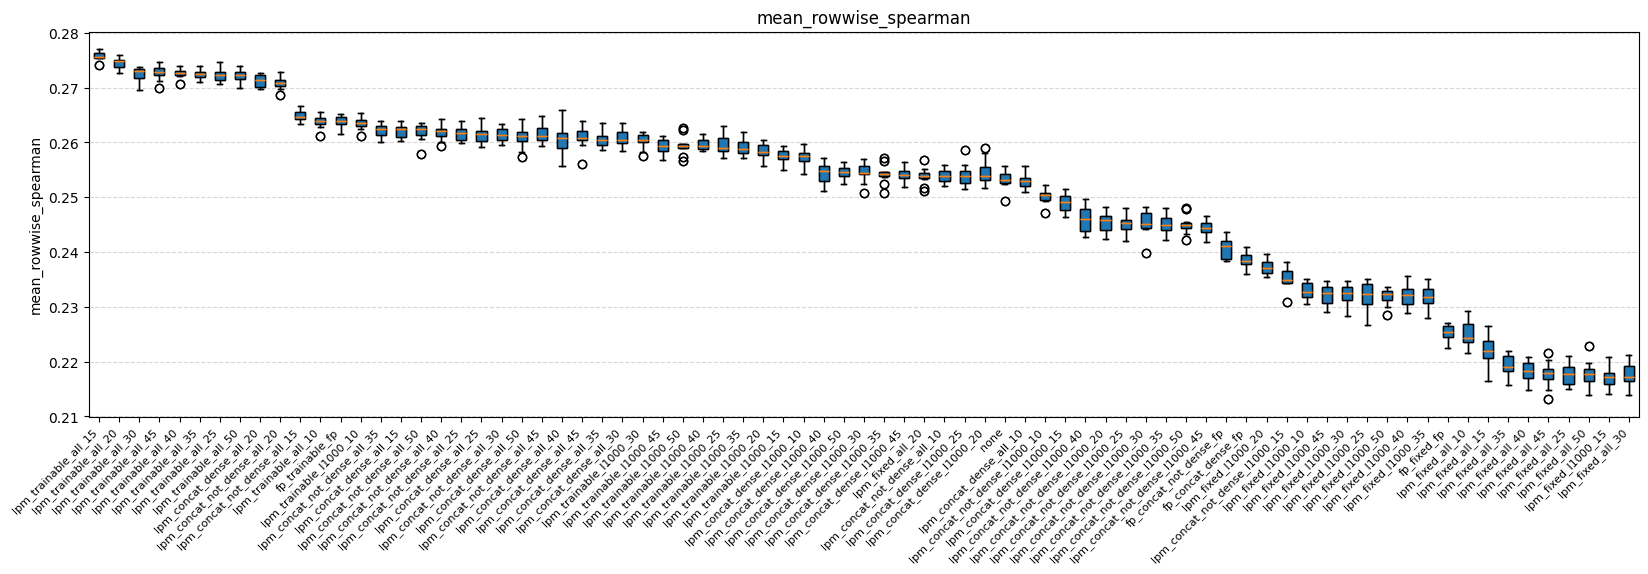

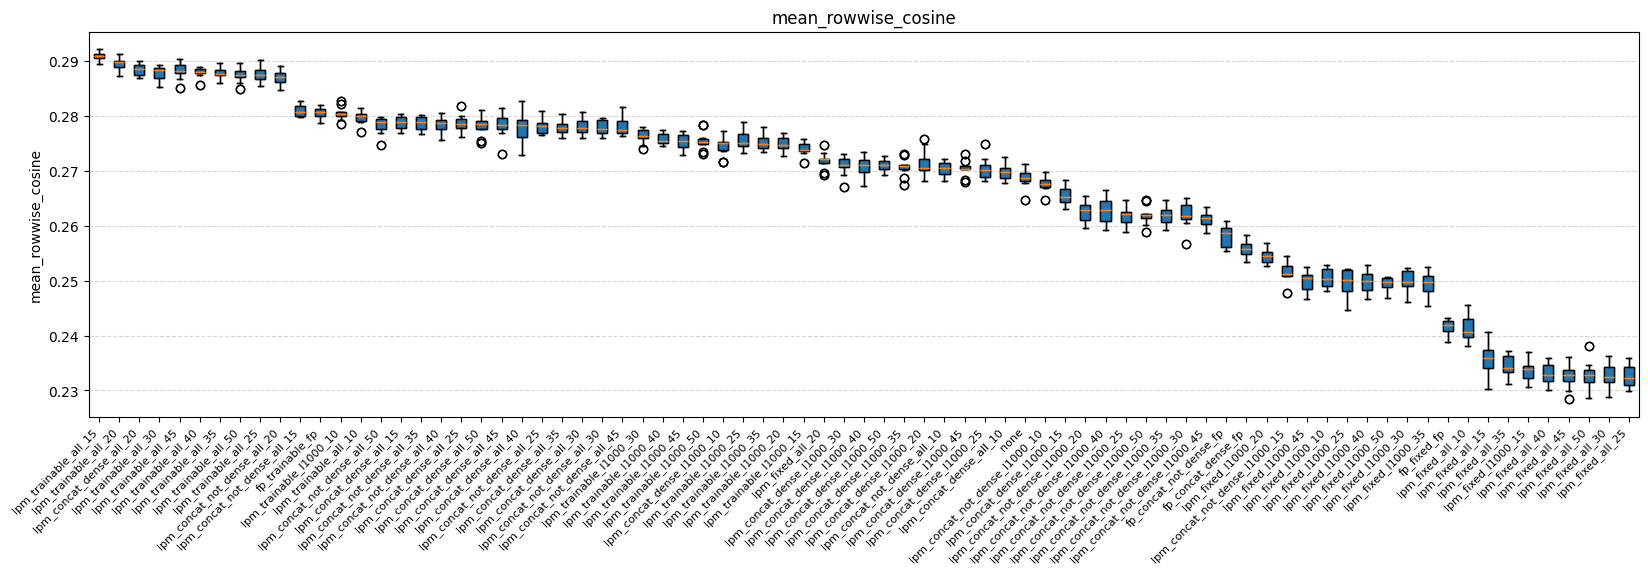

In [33]:
corr_metrics = ["mean_rowwise_pearson", "mean_rowwise_spearman", "mean_rowwise_cosine"]
for metric in corr_metrics:
    # higher correlation is better → sort descending
    methods_ordered = (
        df_method_corr.groupby("method_name")[metric]
        .median()
        .sort_values(ascending=False)
        .index.tolist()
    )
    data_per_method = [
        df_method_corr.loc[df_method_corr["method_name"] == m, metric].values
        for m in methods_ordered
    ]
    plt.figure(figsize=(20, 5))
    plt.boxplot(data_per_method, patch_artist=True, vert=True)
    plt.boxplot(data_per_method, patch_artist=True, vert=True)

    plt.xticks(
        range(1, len(methods_ordered) + 1),
        [m.replace("nn_retraining_with_pseudolabels_mol_emb_subsample_", "") for m in methods_ordered],
        rotation=45, ha="right", fontsize=8,
    )
    plt.ylabel(metric)
    plt.title(metric)
    plt.grid(axis="y", linestyle="--", alpha=0.5)

    plt.show()

In [20]:
df_method_err_ = pd.read_csv('../../data_lpm_style_learning_missed_25_epochs/benchmark/results/metrics/method_err.csv')
df_method_corr_ = pd.read_csv('../../data_lpm_style_learning_missed_25_epochs/benchmark/results/metrics/method_corr.csv')